In [1]:
# Author: Wiktor Sosnowski, 348561

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import json
import os

os.makedirs('results/assignment_06', exist_ok=True)
os.makedirs('plots/assignment_06', exist_ok=True)

## Q-Learning Implementation

In [2]:
class QLearningAgent:
    """
    Tabular Q-learning agent for environments with discrete state and action spaces.
    """

    def __init__(self, n_states, n_actions, alpha=0.5, gamma=0.99, epsilon=0.1):
        """
        n_states  : number of discrete states
        n_actions : number of discrete actions
        alpha     : learning rate
        gamma     : discount factor
        epsilon   : exploration rate for epsilon-greedy policy
        """
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        # Q-table initialised to zeros
        self.Q = np.zeros((n_states, n_actions))

    def select_action(self, state, greedy=False):
        """Epsilon-greedy action selection. If greedy=True, always exploit."""
        if not greedy and np.random.rand() < self.epsilon:
            return np.random.randint(self.Q.shape[1])
        return int(np.argmax(self.Q[state]))

    def update(self, state, action, reward, next_state, done):
        """Single Q-learning update step (off-policy TD)."""
        best_next = 0.0 if done else np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error

    def reset_q_table(self):
        """Reset Q-table to zeros (used between independent runs)."""
        self.Q[:] = 0.0

In [3]:
def train(env, agent, num_episodes):
    """Train agent for num_episodes episodes. Returns list of total rewards per episode."""
    episode_rewards = []
    for _ in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0
        done = False
        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(state, action, reward, next_state, done)
            state = next_state
            total_reward += reward
        episode_rewards.append(total_reward)
    return episode_rewards


def evaluate(env, agent):
    """Run one greedy episode (epsilon=0). Returns (total_reward, num_steps).
    Capped at 200 steps to handle untrained agents that loop indefinitely."""
    state, _ = env.reset()
    total_reward = 0
    num_steps = 0
    done = False
    while not done and num_steps < 200:
        action = agent.select_action(state, greedy=True)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = next_state
        total_reward += reward
        num_steps += 1
    return total_reward, num_steps


def run_experiment(env, n_states, n_actions, alpha, gamma, epsilon,
                   num_episodes, n_runs=25, seed_base=0):
    """Repeat train+evaluate n_runs times with independent Q-tables."""
    rewards = []
    steps   = []
    training_curves = []

    agent = QLearningAgent(n_states, n_actions, alpha=alpha,
                           gamma=gamma, epsilon=epsilon)

    for run in range(n_runs):
        np.random.seed(seed_base + run)
        agent.reset_q_table()
        curve = train(env, agent, num_episodes)
        r, s  = evaluate(env, agent)
        rewards.append(r)
        steps.append(s)
        training_curves.append(curve)

    return np.array(rewards), np.array(steps), np.array(training_curves)


def aggregate(values):
    """Return (min, mean, std, max) rounded to 2 decimal places."""
    return (round(float(np.min(values)),  2),
            round(float(np.mean(values)), 2),
            round(float(np.std(values)),  2),
            round(float(np.max(values)),  2))

## Environment Setup

In [4]:
# CliffWalking-v1 with is_slippery=False is equivalent to the deprecated v0
env = gym.make('CliffWalking-v1')

N_STATES  = env.observation_space.n   # 48 (4x12 grid)
N_ACTIONS = env.action_space.n        # 4 (up, right, down, left)
N_RUNS    = 25

print(f"Environment : CliffWalking-v1 (is_slippery=False)")
print(f"States      : {N_STATES}")
print(f"Actions     : {N_ACTIONS}")

Environment : CliffWalking-v1 (is_slippery=False)
States      : 48
Actions     : 4


## Baseline

**Parameters:** alpha=0.5, gamma=0.99, epsilon=0.1, num_episodes=500, n_runs=25

In [5]:
BASELINE = dict(alpha=0.5, gamma=0.99, epsilon=0.1, num_episodes=500)

base_rewards, base_steps, base_curves = run_experiment(
    env, N_STATES, N_ACTIONS, n_runs=N_RUNS, **BASELINE
)

br = aggregate(base_rewards)
bs = aggregate(base_steps)
print(f"Baseline (25 runs):")
print(f"  Reward | min={br[0]}, mean={br[1]}, std={br[2]}, max={br[3]}")
print(f"  Steps  | min={bs[0]}, mean={bs[1]}, std={bs[2]}, max={bs[3]}")

Baseline (25 runs):
  Reward | min=-13.0, mean=-13.0, std=0.0, max=-13.0
  Steps  | min=13.0, mean=13.0, std=0.0, max=13.0


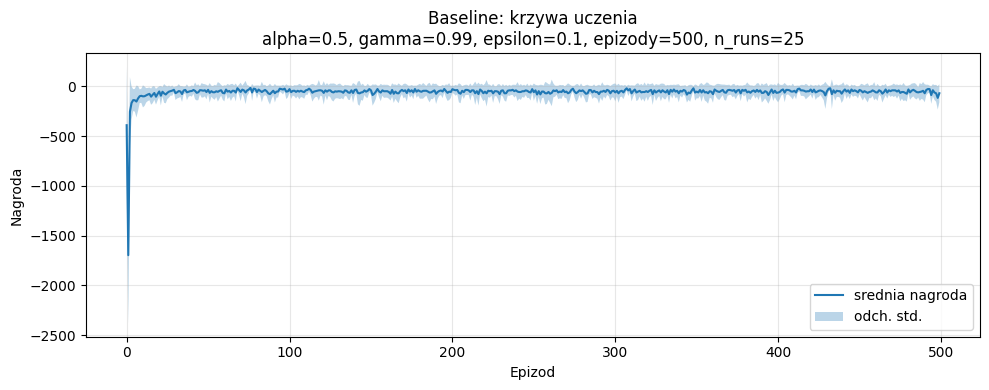

Saved: plots/assignment_06/baseline_learning_curve.png


In [6]:
# Baseline learning curve (mean +/- std across 25 runs)
mean_curve = base_curves.mean(axis=0)
std_curve  = base_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(mean_curve, label='srednia nagroda')
ax.fill_between(range(len(mean_curve)),
                mean_curve - std_curve,
                mean_curve + std_curve, alpha=0.3, label='odch. std.')
ax.set_xlabel('Epizod')
ax.set_ylabel('Nagroda')
ax.set_title('Baseline: krzywa uczenia\nalpha=0.5, gamma=0.99, epsilon=0.1, epizody=500, n_runs=25')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/assignment_06/baseline_learning_curve.png', dpi=150)
plt.show()
print("Saved: plots/assignment_06/baseline_learning_curve.png")

# Save baseline stats
baseline_stats = {
    'config': BASELINE, 'n_runs': N_RUNS,
    'reward': {'min': br[0], 'mean': br[1], 'std': br[2], 'max': br[3]},
    'steps':  {'min': bs[0], 'mean': bs[1], 'std': bs[2], 'max': bs[3]},
}
with open('results/assignment_06/baseline.json', 'w') as f:
    json.dump(baseline_stats, f, indent=2)

## Experiment 1 - Effect of Learning Rate (alpha)

**Fixed:** gamma=0.99, epsilon=0.1, num_episodes=100  
**Varied:** alpha in {0.1, 0.3, 0.5, 0.7, 0.9}

In [7]:
ALPHA_VALUES = [0.1, 0.3, 0.5, 0.7, 0.9]
alpha_rows = []
alpha_curves_all = {}

for alpha in ALPHA_VALUES:
    rewards, steps, curves = run_experiment(
        env, N_STATES, N_ACTIONS,
        alpha=alpha, gamma=0.99, epsilon=0.1, num_episodes=100, n_runs=N_RUNS
    )
    alpha_curves_all[alpha] = curves
    r_min, r_mean, r_std, r_max = aggregate(rewards)
    s_min, s_mean, s_std, s_max = aggregate(steps)
    alpha_rows.append({
        'alpha': alpha,
        'reward_min': r_min, 'reward_mean': r_mean,
        'reward_std': r_std, 'reward_max': r_max,
        'steps_min':  s_min, 'steps_mean':  s_mean,
        'steps_std':  s_std, 'steps_max':   s_max,
    })
    print(f"alpha={alpha:.1f} | reward mean={r_mean:7.2f}, std={r_std:6.2f} | steps mean={s_mean:.2f}, std={s_std:.2f}")

df_alpha = pd.DataFrame(alpha_rows)

alpha=0.1 | reward mean=-200.00, std=  0.00 | steps mean=200.00, std=0.00
alpha=0.3 | reward mean= -20.56, std= 36.63 | steps mean=20.56, std=36.63
alpha=0.5 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00
alpha=0.7 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00
alpha=0.9 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00


In [8]:
print("Tabela 1a - Nagroda vs alpha (gamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25)")
print(df_alpha[['alpha','reward_min','reward_mean','reward_std','reward_max']].to_string(index=False))
print()
print("Tabela 1b - Liczba kroków vs alpha (gamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25)")
print(df_alpha[['alpha','steps_min','steps_mean','steps_std','steps_max']].to_string(index=False))

Tabela 1a - Nagroda vs alpha (gamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25)
 alpha  reward_min  reward_mean  reward_std  reward_max
   0.1      -200.0      -200.00        0.00      -200.0
   0.3      -200.0       -20.56       36.63       -13.0
   0.5       -13.0       -13.00        0.00       -13.0
   0.7       -13.0       -13.00        0.00       -13.0
   0.9       -13.0       -13.00        0.00       -13.0

Tabela 1b - Liczba kroków vs alpha (gamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25)
 alpha  steps_min  steps_mean  steps_std  steps_max
   0.1      200.0      200.00       0.00      200.0
   0.3       13.0       20.56      36.63      200.0
   0.5       13.0       13.00       0.00       13.0
   0.7       13.0       13.00       0.00       13.0
   0.9       13.0       13.00       0.00       13.0


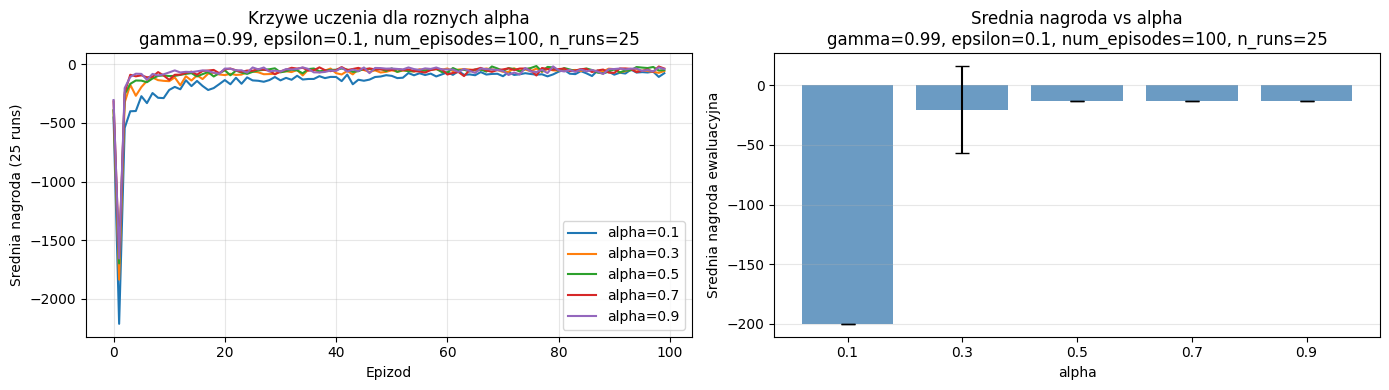

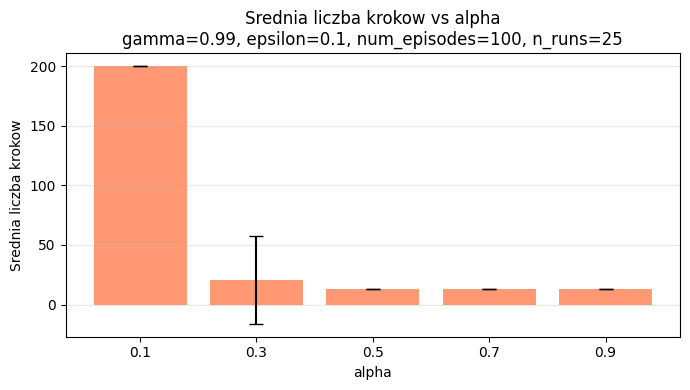

Saved: experiment1_alpha.png, experiment1_alpha_steps.png, experiment1_alpha.csv


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for alpha in ALPHA_VALUES:
    mc = alpha_curves_all[alpha].mean(axis=0)
    axes[0].plot(mc, label=f'alpha={alpha}')
axes[0].set_xlabel('Epizod')
axes[0].set_ylabel('Srednia nagroda (25 runs)')
axes[0].set_title('Krzywe uczenia dla roznych alpha\ngamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar([str(a) for a in ALPHA_VALUES], df_alpha['reward_mean'],
            yerr=df_alpha['reward_std'], capsize=5, color='steelblue', alpha=0.8)
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('Srednia nagroda ewaluacyjna')
axes[1].set_title('Srednia nagroda vs alpha\ngamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/assignment_06/experiment1_alpha.png', dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.bar([str(a) for a in ALPHA_VALUES], df_alpha['steps_mean'],
        yerr=df_alpha['steps_std'], capsize=5, color='coral', alpha=0.8)
ax2.set_xlabel('alpha')
ax2.set_ylabel('Srednia liczba krokow')
ax2.set_title('Srednia liczba krokow vs alpha\ngamma=0.99, epsilon=0.1, num_episodes=100, n_runs=25')
ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('plots/assignment_06/experiment1_alpha_steps.png', dpi=150)
plt.show()

df_alpha.to_csv('results/assignment_06/experiment1_alpha.csv', index=False)
print("Saved: experiment1_alpha.png, experiment1_alpha_steps.png, experiment1_alpha.csv")

## Experiment 2 - Effect of Number of Training Episodes

**Fixed:** alpha=0.5, gamma=0.99, epsilon=0.1  
**Varied:** num_episodes in {10, 20, 30, 50, 75, 100, 200, 500}

In [10]:
EPISODE_VALUES = [10, 20, 30, 50, 75, 100, 200, 500]
eps_rows = []

for num_ep in EPISODE_VALUES:
    rewards, steps, _ = run_experiment(
        env, N_STATES, N_ACTIONS,
        alpha=0.5, gamma=0.99, epsilon=0.1, num_episodes=num_ep, n_runs=N_RUNS
    )
    r_min, r_mean, r_std, r_max = aggregate(rewards)
    s_min, s_mean, s_std, s_max = aggregate(steps)
    eps_rows.append({
        'num_episodes': num_ep,
        'reward_min': r_min, 'reward_mean': r_mean,
        'reward_std': r_std, 'reward_max': r_max,
        'steps_min':  s_min, 'steps_mean':  s_mean,
        'steps_std':  s_std, 'steps_max':   s_max,
    })
    print(f"episodes={num_ep:4d} | reward mean={r_mean:7.2f}, std={r_std:6.2f} | steps mean={s_mean:.2f}, std={s_std:.2f}")

df_episodes = pd.DataFrame(eps_rows)

episodes=  10 | reward mean=-200.00, std=  0.00 | steps mean=200.00, std=0.00
episodes=  20 | reward mean=-200.00, std=  0.00 | steps mean=200.00, std=0.00
episodes=  30 | reward mean=-200.00, std=  0.00 | steps mean=200.00, std=0.00
episodes=  50 | reward mean= -95.28, std= 92.82 | steps mean=95.28, std=92.82
episodes=  75 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00
episodes= 100 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00
episodes= 200 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00
episodes= 500 | reward mean= -13.00, std=  0.00 | steps mean=13.00, std=0.00


In [11]:
print("Tabela 2a - Nagroda vs liczba epizodow (alpha=0.5, gamma=0.99, epsilon=0.1, n_runs=25)")
print(df_episodes[['num_episodes','reward_min','reward_mean','reward_std','reward_max']].to_string(index=False))
print()
print("Tabela 2b - Liczba kroków vs liczba epizodow")
print(df_episodes[['num_episodes','steps_min','steps_mean','steps_std','steps_max']].to_string(index=False))

Tabela 2a - Nagroda vs liczba epizodow (alpha=0.5, gamma=0.99, epsilon=0.1, n_runs=25)
 num_episodes  reward_min  reward_mean  reward_std  reward_max
           10      -200.0      -200.00        0.00      -200.0
           20      -200.0      -200.00        0.00      -200.0
           30      -200.0      -200.00        0.00      -200.0
           50      -200.0       -95.28       92.82       -13.0
           75       -13.0       -13.00        0.00       -13.0
          100       -13.0       -13.00        0.00       -13.0
          200       -13.0       -13.00        0.00       -13.0
          500       -13.0       -13.00        0.00       -13.0

Tabela 2b - Liczba kroków vs liczba epizodow
 num_episodes  steps_min  steps_mean  steps_std  steps_max
           10      200.0      200.00       0.00      200.0
           20      200.0      200.00       0.00      200.0
           30      200.0      200.00       0.00      200.0
           50       13.0       95.28      92.82      200.0
     

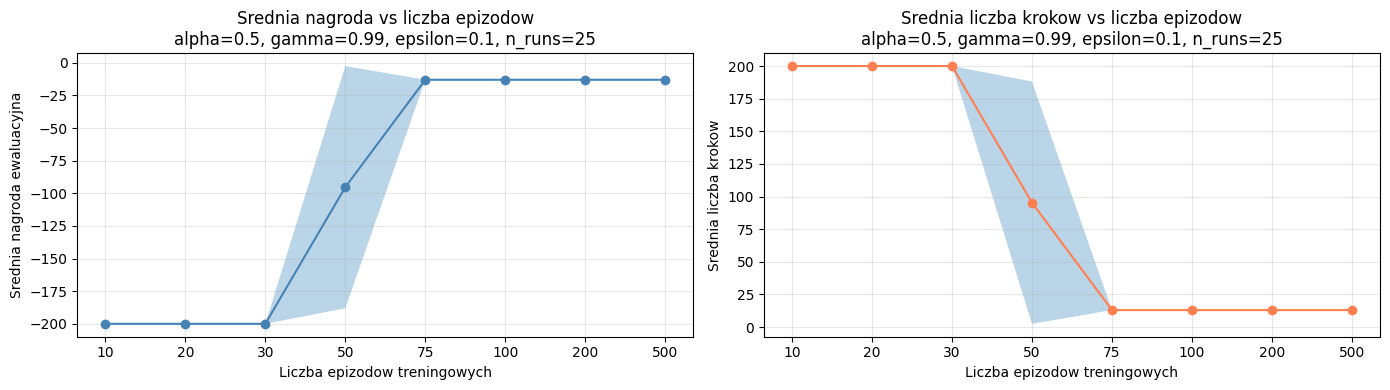

Saved: experiment2_episodes.png, experiment2_episodes.csv


In [12]:
ep_labels = [str(n) for n in EPISODE_VALUES]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ep_labels, df_episodes['reward_mean'], marker='o', color='steelblue')
axes[0].fill_between(ep_labels,
                     df_episodes['reward_mean'] - df_episodes['reward_std'],
                     df_episodes['reward_mean'] + df_episodes['reward_std'],
                     alpha=0.3)
axes[0].set_xlabel('Liczba epizodow treningowych')
axes[0].set_ylabel('Srednia nagroda ewaluacyjna')
axes[0].set_title('Srednia nagroda vs liczba epizodow\nalpha=0.5, gamma=0.99, epsilon=0.1, n_runs=25')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep_labels, df_episodes['steps_mean'], marker='o', color='coral')
axes[1].fill_between(ep_labels,
                     df_episodes['steps_mean'] - df_episodes['steps_std'],
                     df_episodes['steps_mean'] + df_episodes['steps_std'],
                     alpha=0.3)
axes[1].set_xlabel('Liczba epizodow treningowych')
axes[1].set_ylabel('Srednia liczba krokow')
axes[1].set_title('Srednia liczba krokow vs liczba epizodow\nalpha=0.5, gamma=0.99, epsilon=0.1, n_runs=25')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/assignment_06/experiment2_episodes.png', dpi=150)
plt.show()

df_episodes.to_csv('results/assignment_06/experiment2_episodes.csv', index=False)
print("Saved: experiment2_episodes.png, experiment2_episodes.csv")

## Summary

In [13]:
print("=" * 65)
print("BASELINE (alpha=0.5, gamma=0.99, epsilon=0.1, num_episodes=500)")
print(f"  Reward | min={br[0]}, mean={br[1]}, std={br[2]}, max={br[3]}")
print(f"  Steps  | min={bs[0]}, mean={bs[1]}, std={bs[2]}, max={bs[3]}")
print()
print("=" * 65)
print("EXPERIMENT 1 - alpha (gamma=0.99, epsilon=0.1, num_episodes=100)")
print(df_alpha[['alpha','reward_mean','reward_std','steps_mean','steps_std']].to_string(index=False))
print()
print("=" * 65)
print("EXPERIMENT 2 - episodes (alpha=0.5, gamma=0.99, epsilon=0.1)")
print(df_episodes[['num_episodes','reward_mean','reward_std','steps_mean','steps_std']].to_string(index=False))

env.close()

BASELINE (alpha=0.5, gamma=0.99, epsilon=0.1, num_episodes=500)
  Reward | min=-13.0, mean=-13.0, std=0.0, max=-13.0
  Steps  | min=13.0, mean=13.0, std=0.0, max=13.0

EXPERIMENT 1 - alpha (gamma=0.99, epsilon=0.1, num_episodes=100)
 alpha  reward_mean  reward_std  steps_mean  steps_std
   0.1      -200.00        0.00      200.00       0.00
   0.3       -20.56       36.63       20.56      36.63
   0.5       -13.00        0.00       13.00       0.00
   0.7       -13.00        0.00       13.00       0.00
   0.9       -13.00        0.00       13.00       0.00

EXPERIMENT 2 - episodes (alpha=0.5, gamma=0.99, epsilon=0.1)
 num_episodes  reward_mean  reward_std  steps_mean  steps_std
           10      -200.00        0.00      200.00       0.00
           20      -200.00        0.00      200.00       0.00
           30      -200.00        0.00      200.00       0.00
           50       -95.28       92.82       95.28      92.82
           75       -13.00        0.00       13.00       0.00
   